In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

In [2]:
# -------------------------
# CONFIG
# -------------------------
ROOT = r"D:\ML\env\notebook\data"
CSV  = r"D:\ML\env\notebook\data\train_metadata.csv"

IMG_SIZE = 256
BATCH_SIZE = 2
EPOCHS = 30
BANDS = ["B02","B03","B04","B08"]

# Determine device (This is how PyTorch accesses your NVIDIA GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------------
# LOAD & FILTER METADATA
# -------------------------
metadata = pd.read_csv(CSV)
valid = []

for _, row in metadata.iterrows():
    chip = row["chip_id"]
    ok = True
    
    for b in BANDS:
        p = os.path.join(ROOT, "train_features", chip, f"{b}.tif")
        if not os.path.exists(p):
            ok = False
            break
            
    if ok:
        valid.append(row)

metadata = pd.DataFrame(valid)
print("Final usable samples:", len(metadata))

Using device: cuda
Final usable samples: 11748


In [3]:
# -------------------------
# DATASET SPLIT
# -------------------------
train_meta, temp = train_test_split(metadata, test_size=0.3, random_state=42)
val_meta, _ = train_test_split(temp, test_size=2/3, random_state=42)

# -------------------------
# PYTORCH DATASET CLASS
# -------------------------
class CloudDataset(Dataset):
    def __init__(self, dataframe, root_dir, img_size):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        chip = self.df.loc[idx, "chip_id"]
        feature_dir = os.path.join(self.root_dir, "train_features", chip)
        label_path  = os.path.join(self.root_dir, "train_labels", f"{chip}.tif")

        # Read bands and stack them into (Channels, Height, Width)
        bands = []
        for b in ["B02","B03","B04","B08"]:
            with rasterio.open(os.path.join(feature_dir, f"{b}.tif")) as src:
                # rasterio reads as (1, H, W), we grab the [0] to get (H, W)
                x = src.read(1).astype(np.float32) / 65535.0
            bands.append(x)
        
        # Stack on axis 0 to get (4, H, W)
        X = np.stack(bands, axis=0)
        
        # Read label and expand to (1, H, W)
        with rasterio.open(label_path) as src:
            y = src.read(1).astype(np.float32)[np.newaxis, ...]

        # Convert to PyTorch tensors
        X_tensor = torch.from_numpy(X)
        y_tensor = torch.from_numpy(y)

        # Resize tensors
        X_resized = TF.resize(X_tensor, [self.img_size, self.img_size], antialias=True)
        y_resized = TF.resize(y_tensor, [self.img_size, self.img_size], antialias=True)

        return X_resized, y_resized

# -------------------------
# INITIALIZE DATALOADERS
# -------------------------
train_dataset = CloudDataset(train_meta, ROOT, IMG_SIZE)
val_dataset = CloudDataset(val_meta, ROOT, IMG_SIZE)

# num_workers speeds up data loading (similar to AUTOTUNE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

In [4]:
# -------------------------
# PYTORCH UNET MODEL (For 256x256)
# -------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.c1 = DoubleConv(in_channels, 16)
        self.c2 = DoubleConv(16, 32)
        self.c3 = DoubleConv(32, 64)
        self.c4 = DoubleConv(64, 128) 

        self.bn = DoubleConv(128, 256) 

        self.c5 = DoubleConv(256 + 128, 128) 
        self.c6 = DoubleConv(128 + 64, 64)
        self.c7 = DoubleConv(64 + 32, 32)
        self.c8 = DoubleConv(32 + 16, 16)

        self.out = nn.Sequential(
            nn.Conv2d(16, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        c1 = self.c1(x); p1 = self.pool(c1)
        c2 = self.c2(p1); p2 = self.pool(c2)
        c3 = self.c3(p2); p3 = self.pool(c3)
        c4 = self.c4(p3); p4 = self.pool(c4)

        bn = self.bn(p4)

        u4 = self.up(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.c5(u4)

        u3 = self.up(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.c6(u3)

        u2 = self.up(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.c7(u2)

        u1 = self.up(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.c8(u1)

        return self.out(c8)

model = UNet().to(device)

In [5]:
# -------------------------
# METRICS FUNCTION
# -------------------------
def calculate_metrics(y_pred, y_true):
    # Threshold the sigmoid output
    preds = (y_pred > 0.5).float()
    
    tp = (preds * y_true).sum()
    fp = (preds * (1 - y_true)).sum()
    fn = ((1 - preds) * y_true).sum()
    
    acc = (preds == y_true).float().mean()
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    
    return acc.item(), precision.item(), recall.item(), iou.item()



In [6]:
from tqdm import tqdm

# -------------------------
# COMPILE (Setup Loss & Optimizer)
# -------------------------
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -------------------------
# TRAIN
# -------------------------
history = {'loss': [], 'accuracy': [], 'precision': [], 'recall': [], 'iou': [],
           'val_loss': [], 'val_accuracy': [], 'val_precision': [], 'val_recall': [], 'val_iou': []}

for epoch in range(EPOCHS):
    model.train() 
    train_metrics = np.zeros(5) 
    
    # ADDED TQDM HERE FOR A PROGRESS BAR
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        
        loss.backward()
        optimizer.step()
        
        acc, prec, rec, iou = calculate_metrics(preds, y_batch)
        train_metrics += np.array([loss.item(), acc, prec, rec, iou])
        
        # Update the progress bar with the current loss
        loop.set_postfix(loss=loss.item(), iou=iou)
        
    train_metrics /= len(train_loader)
    
    # Validation loop
    model.eval() 
    val_metrics = np.zeros(5)
    
    # ADDED TQDM HERE AS WELL
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")
    
    with torch.no_grad():
        for X_batch, y_batch in val_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            
            acc, prec, rec, iou = calculate_metrics(preds, y_batch)
            val_metrics += np.array([loss.item(), acc, prec, rec, iou])
            
    val_metrics /= len(val_loader)
    
    # Store history
    history['loss'].append(train_metrics[0])
    history['accuracy'].append(train_metrics[1])
    history['precision'].append(train_metrics[2])
    history['recall'].append(train_metrics[3])
    history['iou'].append(train_metrics[4])
    
    history['val_loss'].append(val_metrics[0])
    history['val_accuracy'].append(val_metrics[1])
    history['val_precision'].append(val_metrics[2])
    history['val_recall'].append(val_metrics[3])
    history['val_iou'].append(val_metrics[4])
    
    # Final print for the epoch
    print(f"--> Epoch {epoch+1} Summary: "
          f"loss: {train_metrics[0]:.4f} - iou: {train_metrics[4]:.4f} - "
          f"val_loss: {val_metrics[0]:.4f} - val_iou: {val_metrics[4]:.4f}\n")

Epoch 1/30 [Val]: 100%|██████████████████████████████████████████████████████████████| 588/588 [00:36<00:00, 16.00it/s]


--> Epoch 1 Summary: loss: 0.3928 - iou: 0.7346 - val_loss: 0.3390 - val_iou: 0.7634



Epoch 2/30 [Val]: 100%|██████████████████████████████████████████████████████████████| 588/588 [00:36<00:00, 16.10it/s]


--> Epoch 2 Summary: loss: 0.3447 - iou: 0.7650 - val_loss: 0.3421 - val_iou: 0.7716



Epoch 3/30 [Val]: 100%|██████████████████████████████████████████████████████████████| 588/588 [00:37<00:00, 15.81it/s]


...

--> Epoch 28 Summary: loss: 0.2393 - iou: 0.8484 - val_loss: 0.2316 - val_iou: 0.8464



Epoch 29/30 [Val]: 100%|█████████████████████████████████████████████████████████████| 588/588 [00:42<00:00, 13.69it/s]


--> Epoch 29 Summary: loss: 0.2811 - iou: 0.8228 - val_loss: 0.3253 - val_iou: 0.7873



Epoch 30/30 [Val]: 100%|█████████████████████████████████████████████████████████████| 588/588 [00:42<00:00, 13.96it/s]

--> Epoch 30 Summary: loss: 0.2957 - iou: 0.8046 - val_loss: 0.2837 - val_iou: 0.8026



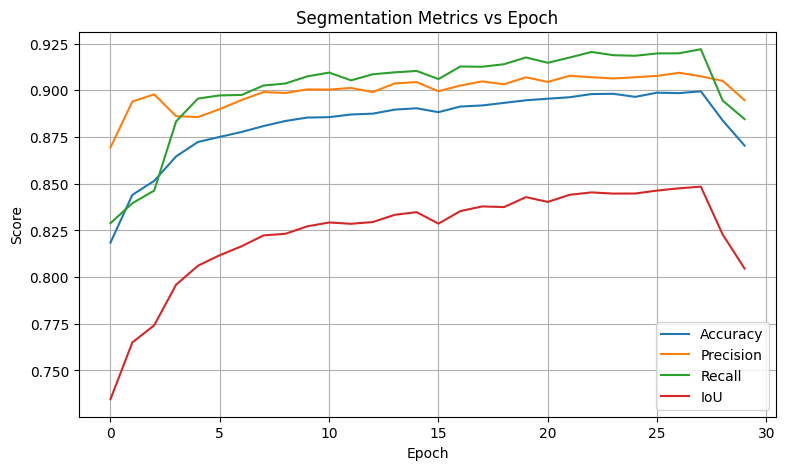

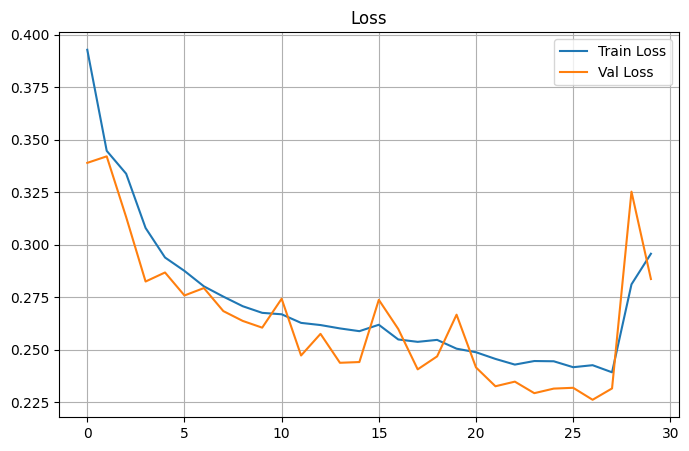

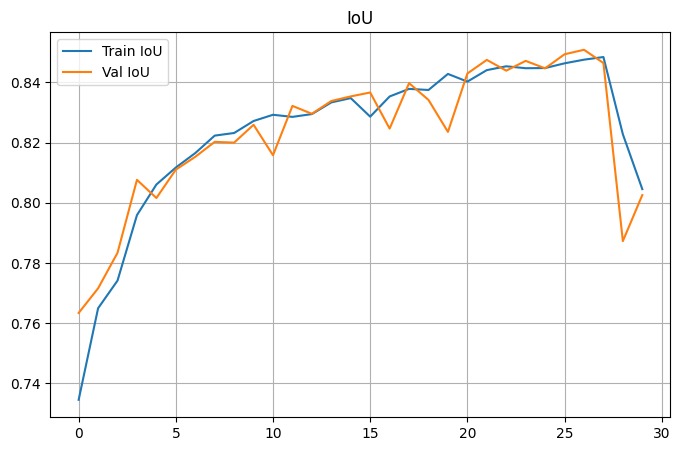

Saved model: pytorch_unet_cloud_30epochfix_256img.pth


In [7]:
# -------------------------
# SEGMENTATION METRICS vs EPOCH
# -------------------------
plt.figure(figsize=(9,5))
plt.plot(history["accuracy"], label="Accuracy")
plt.plot(history["precision"], label="Precision")
plt.plot(history["recall"], label="Recall")
plt.plot(history["iou"], label="IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Segmentation Metrics vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# PLOT CURVES
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(history["loss"])
plt.plot(history["val_loss"])
plt.legend(["Train Loss","Val Loss"])
plt.grid(True)
plt.title("Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history["iou"])
plt.plot(history["val_iou"])
plt.legend(["Train IoU","Val IoU"])
plt.grid(True)
plt.title("IoU")
plt.show()

# -------------------------
# SAVE MODEL
# -------------------------
torch.save(model.state_dict(), "pytorch_unet_cloud_30epochfix_256img.pth")
print("Saved model: pytorch_unet_cloud_30epochfix_256img.pth")